![PIC UPV PERTE Chip Chair Logo](https://www.pic-chair.upv.es/wp-content/uploads/2024/05/logo-upv-horizontal.png)
![PIC UPV PERTE Chip Chair Logo](https://www.pic-chair.upv.es/wp-content/uploads/2024/06/logos-perte-chip-1024x119.png)


# Laboratory 3. Interferometers I - MZI


Today we will work on the design and modeling of an **Mach-Zenhder Interferometer (MZI)** used in integrated photonic circuits. We will perform simulations that will allow us to understand how it operates.


## 0.1 General libraries

In [9]:
import gdsfactory as gf
import jax
import jax.example_libraries.optimizers as opt
import jax.numpy as jnp
import matplotlib.pyplot as plt
from matplotlib.pyplot import cm

import numpy as np
import sax
from gdsfactory.generic_tech import get_generic_pdk
from scipy import constants
from scipy.constants import c
from scipy.interpolate import interp1d

import gplugins.sax as gs
from gplugins.common.config import PATH

## 1. MZI modeling
Let's compute the transfer function of a MZI

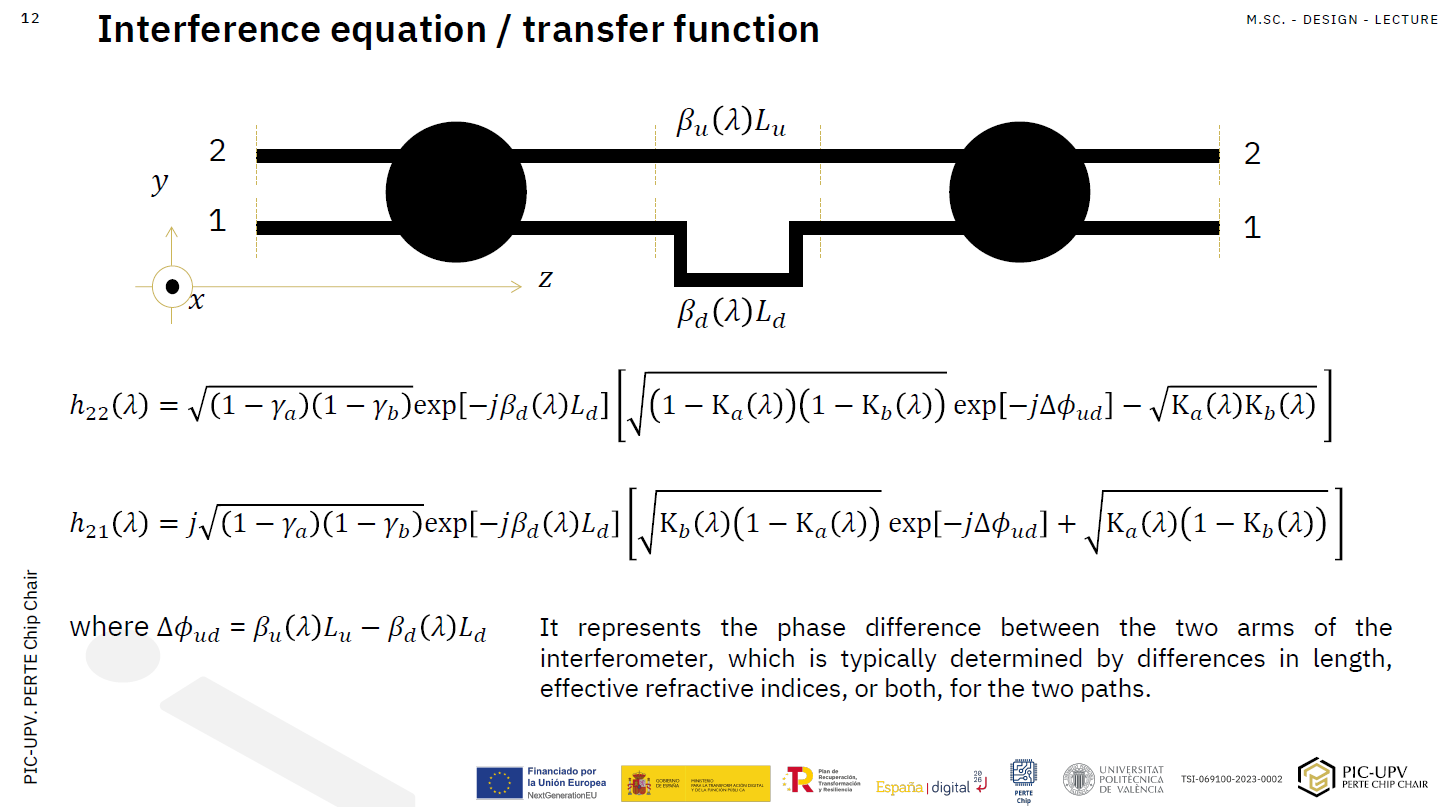

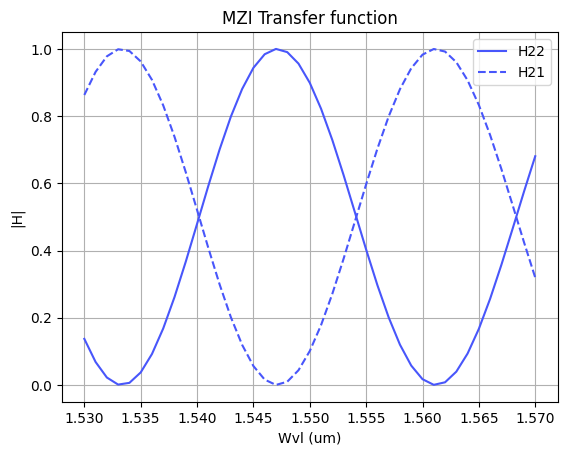

In [10]:
### Waveguides configuration ###

## Propagation parameters

## SOI cross-section ##
SOI = np.loadtxt('SOI-w450-h220-clad600.txt', skiprows=1, delimiter='\t')

wvl = SOI[:, 0]
neffu = SOI[:, 3] #balanced configuration // (neff TE mode)
neffd = SOI[:, 3] #balanced configuration // (neff TE mode)

## SiN cross-section ##
# SiN_clad = np.loadtxt('SiN-h300nm-w1000nm-Cladding.txt', skiprows=1, delimiter='\t')
# SiN_wat = np.loadtxt('SiN-h300nm-w1000nm-Water.txt', skiprows=1, delimiter='\t')

# wvl0 = SiN_clad[:, 0]
# neffu0 = SiN_clad[:, 3] #balanced configuration // (neff TE mode)
# neffd0 = SiN_wat[:, 3] #balanced configuration // (neff TE mode)

# interp_neffu = interp1d(wvl0, neffu0, kind='cubic')  # Cubic interpolation for smoothness
# interp_neffd = interp1d(wvl0, neffd0, kind='cubic')
# wvl = np.linspace(wvl0.min(), wvl0.max(), 1000)
# neffu = interp_neffu(wvl)
# neffd = interp_neffd(wvl)

# Propagation loss
alphau = 0 #losless case [dB/um]
alphad = 0; #losless case [dB/um]
alphau_np = (jnp.log(10.0)/10.0) * alphau   # neper/um
alphad_np = (jnp.log(10.0)/10.0) * alphad   # neper/um

# Path length
Lu = 25; # um
Ld = 5; # um

betau = (2*jnp.pi/wvl)*neffu-1j*alphau_np
betad = (2*jnp.pi/wvl)*neffd-1j*alphad_np

Delta_phi_ud = betau*Lu - betad*Ld

### Couplers configuration ###
# Excess loss
gamma_a = 0; #null excess loss
gamma_b = 0; #null excess loss

# Coupling constant
K_a = np.full(wvl.shape, 0.5)
K_b = np.full(wvl.shape, 0.5)

# MZI transfer function (h22 & h21)

#  h_22(wvl)
h_22 = (np.sqrt((1 - gamma_a) * (1 - gamma_b)))*(np.exp(-1j * betad * Ld))*(( np.sqrt((1 - K_a) * (1 - K_b)) * np.exp(-1j * Delta_phi_ud))-(np.sqrt(K_a * K_b)))

#  h_21(wvl)
h_21 = (1j * np.sqrt((1 - gamma_a) * (1 - gamma_b)))*(np.exp(-1j * betad * Ld))*((np.sqrt(K_b * (1 - K_a)) * np.exp(-1j * Delta_phi_ud))+(np.sqrt(K_a * (1 - K_b))))

H21 = np.abs(h_21) ** 2
H22 = np.abs(h_22) ** 2

# Plot
color = cm.rainbow(np.linspace(0, 1, 10))

plt.plot(wvl, H22, linestyle='-', color=color[1], label='H22')
plt.plot(wvl, H21, linestyle='--', color=color[1], label='H21')
plt.xlabel('Wvl (um)')
plt.ylabel('|H|')
plt.title('MZI Transfer function')
plt.legend()
plt.grid(True)

plt.show()

**Assesment 1.** Please, provide one example of each one of the configurations studied during MZI lecture:
1. Balenced configuration
2. Unbalanced configuration
  1.   Phase difference
  2.   Delay imbalance

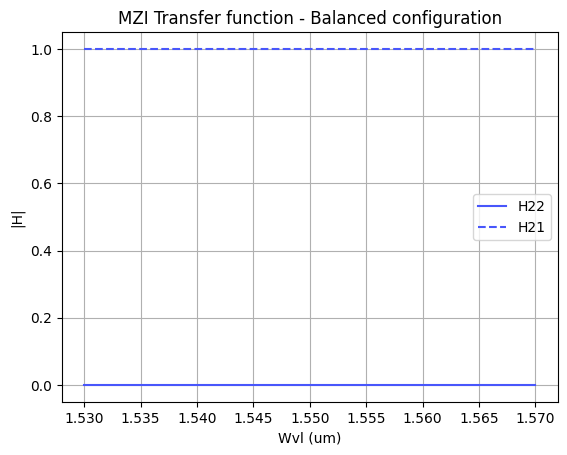

In [11]:
### Waveguides configuration ###

## Propagation parameters

## SOI cross-section ##
SOI = np.loadtxt('SOI-w450-h220-clad600.txt', skiprows=1, delimiter='\t')

wvl = SOI[:, 0]
neffu = SOI[:, 3] #balanced configuration // (neff TE mode)
neffd = SOI[:, 3] #balanced configuration // (neff TE mode)

## SiN cross-section ##
# SiN_clad = np.loadtxt('SiN-h300nm-w1000nm-Cladding.txt', skiprows=1, delimiter='\t')
# SiN_wat = np.loadtxt('SiN-h300nm-w1000nm-Water.txt', skiprows=1, delimiter='\t')

# wvl0 = SiN_clad[:, 0]
# neffu0 = SiN_clad[:, 3] #balanced configuration // (neff TE mode)
# neffd0 = SiN_wat[:, 3] #balanced configuration // (neff TE mode)

# interp_neffu = interp1d(wvl0, neffu0, kind='cubic')  # Cubic interpolation for smoothness
# interp_neffd = interp1d(wvl0, neffd0, kind='cubic')
# wvl = np.linspace(wvl0.min(), wvl0.max(), 1000)
# neffu = interp_neffu(wvl)
# neffd = interp_neffd(wvl)

# Propagation loss
alphau = 0 #losless case [dB/um]
alphad = 0; #losless case [dB/um]
alphau_np = (jnp.log(10.0)/10.0) * alphau   # neper/um
alphad_np = (jnp.log(10.0)/10.0) * alphad   # neper/um

# Path length
Lu = 25; # um
Ld = 25; # um

betau = (2*jnp.pi/wvl)*neffu-1j*alphau_np
betad = (2*jnp.pi/wvl)*neffd-1j*alphad_np

Delta_phi_ud = betau*Lu - betad*Ld

### Couplers configuration ###
# Excess loss
gamma_a = 0; #null excess loss
gamma_b = 0; #null excess loss

# Coupling constant
K_a = np.full(wvl.shape, 0.5)
K_b = np.full(wvl.shape, 0.5)

# MZI transfer function (h22 & h21)

#  h_22(wvl)
h_22 = (np.sqrt((1 - gamma_a) * (1 - gamma_b)))*(np.exp(-1j * betad * Ld))*(( np.sqrt((1 - K_a) * (1 - K_b)) * np.exp(-1j * Delta_phi_ud))-(np.sqrt(K_a * K_b)))

#  h_21(wvl)
h_21 = (1j * np.sqrt((1 - gamma_a) * (1 - gamma_b)))*(np.exp(-1j * betad * Ld))*((np.sqrt(K_b * (1 - K_a)) * np.exp(-1j * Delta_phi_ud))+(np.sqrt(K_a * (1 - K_b))))

H21 = np.abs(h_21) ** 2
H22 = np.abs(h_22) ** 2

# Plot
color = cm.rainbow(np.linspace(0, 1, 10))

plt.plot(wvl, H22, linestyle='-', color=color[1], label='H22')
plt.plot(wvl, H21, linestyle='--', color=color[1], label='H21')
plt.xlabel('Wvl (um)')
plt.ylabel('|H|')
plt.title('MZI Transfer function - Balanced configuration')
plt.legend()
plt.grid(True)

plt.show()

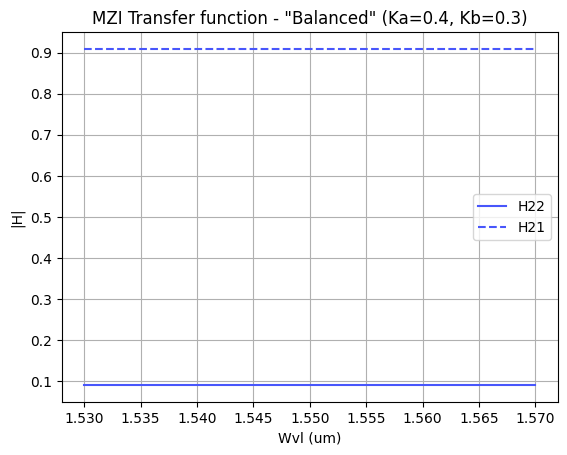

In [12]:
### Waveguides configuration ###

## Propagation parameters

## SOI cross-section ##
SOI = np.loadtxt('SOI-w450-h220-clad600.txt', skiprows=1, delimiter='\t')

wvl = SOI[:, 0]
neffu = SOI[:, 3] #balanced configuration // (neff TE mode)
neffd = SOI[:, 3] #balanced configuration // (neff TE mode)

## SiN cross-section ##
# SiN_clad = np.loadtxt('SiN-h300nm-w1000nm-Cladding.txt', skiprows=1, delimiter='\t')
# SiN_wat = np.loadtxt('SiN-h300nm-w1000nm-Water.txt', skiprows=1, delimiter='\t')

# wvl0 = SiN_clad[:, 0]
# neffu0 = SiN_clad[:, 3] #balanced configuration // (neff TE mode)
# neffd0 = SiN_wat[:, 3] #balanced configuration // (neff TE mode)

# interp_neffu = interp1d(wvl0, neffu0, kind='cubic')  # Cubic interpolation for smoothness
# interp_neffd = interp1d(wvl0, neffd0, kind='cubic')
# wvl = np.linspace(wvl0.min(), wvl0.max(), 1000)
# neffu = interp_neffu(wvl)
# neffd = interp_neffd(wvl)

# Propagation loss
alphau = 0 #losless case [dB/um]
alphad = 0; #losless case [dB/um]
alphau_np = (jnp.log(10.0)/10.0) * alphau   # neper/um
alphad_np = (jnp.log(10.0)/10.0) * alphad   # neper/um

# Path length
Lu = 25; # um
Ld = 25; # um

betau = (2*jnp.pi/wvl)*neffu-1j*alphau_np
betad = (2*jnp.pi/wvl)*neffd-1j*alphad_np

Delta_phi_ud = betau*Lu - betad*Ld

### Couplers configuration ###
# Excess loss
gamma_a = 0; #null excess loss
gamma_b = 0; #null excess loss

# Coupling constant
K_a = np.full(wvl.shape, 0.4)
K_b = np.full(wvl.shape, 0.3)

# MZI transfer function (h22 & h21)

#  h_22(wvl)
h_22 = (np.sqrt((1 - gamma_a) * (1 - gamma_b)))*(np.exp(-1j * betad * Ld))*(( np.sqrt((1 - K_a) * (1 - K_b)) * np.exp(-1j * Delta_phi_ud))-(np.sqrt(K_a * K_b)))

#  h_21(wvl)
h_21 = (1j * np.sqrt((1 - gamma_a) * (1 - gamma_b)))*(np.exp(-1j * betad * Ld))*((np.sqrt(K_b * (1 - K_a)) * np.exp(-1j * Delta_phi_ud))+(np.sqrt(K_a * (1 - K_b))))

H21 = np.abs(h_21) ** 2
H22 = np.abs(h_22) ** 2

# Plot
color = cm.rainbow(np.linspace(0, 1, 10))

plt.plot(wvl, H22, linestyle='-', color=color[1], label='H22')
plt.plot(wvl, H21, linestyle='--', color=color[1], label='H21')
plt.xlabel('Wvl (um)')
plt.ylabel('|H|')
plt.title('MZI Transfer function - "Balanced" (Ka=0.4, Kb=0.3)')
plt.legend()
plt.grid(True)

plt.show()

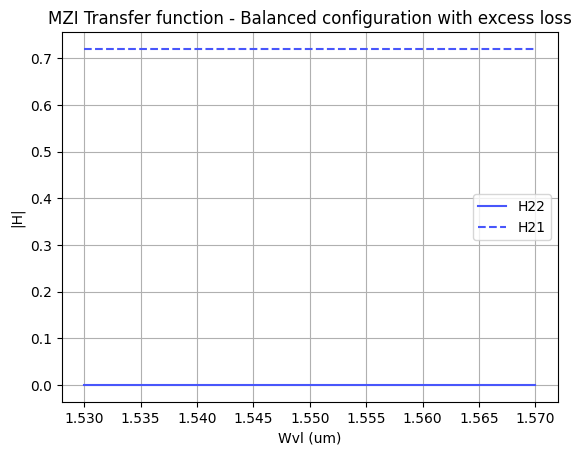

In [13]:
### Waveguides configuration ###

## Propagation parameters

## SOI cross-section ##
SOI = np.loadtxt('SOI-w450-h220-clad600.txt', skiprows=1, delimiter='\t')

wvl = SOI[:, 0]
neffu = SOI[:, 3] #balanced configuration // (neff TE mode)
neffd = SOI[:, 3] #balanced configuration // (neff TE mode)

## SiN cross-section ##
# SiN_clad = np.loadtxt('SiN-h300nm-w1000nm-Cladding.txt', skiprows=1, delimiter='\t')
# SiN_wat = np.loadtxt('SiN-h300nm-w1000nm-Water.txt', skiprows=1, delimiter='\t')

# wvl0 = SiN_clad[:, 0]
# neffu0 = SiN_clad[:, 3] #balanced configuration // (neff TE mode)
# neffd0 = SiN_wat[:, 3] #balanced configuration // (neff TE mode)

# interp_neffu = interp1d(wvl0, neffu0, kind='cubic')  # Cubic interpolation for smoothness
# interp_neffd = interp1d(wvl0, neffd0, kind='cubic')
# wvl = np.linspace(wvl0.min(), wvl0.max(), 1000)
# neffu = interp_neffu(wvl)
# neffd = interp_neffd(wvl)

# Propagation loss
alphau = 0 #losless case [dB/um]
alphad = 0; #losless case [dB/um]
alphau_np = (jnp.log(10.0)/10.0) * alphau   # neper/um
alphad_np = (jnp.log(10.0)/10.0) * alphad   # neper/um

# Path length
Lu = 25; # um
Ld = 25; # um

betau = (2*jnp.pi/wvl)*neffu-1j*alphau_np
betad = (2*jnp.pi/wvl)*neffd-1j*alphad_np

Delta_phi_ud = betau*Lu - betad*Ld

### Couplers configuration ###
# Excess loss
gamma_a = 0.2; #null excess loss
gamma_b = 0.1; #null excess loss

# Coupling constant
K_a = np.full(wvl.shape, 0.5)
K_b = np.full(wvl.shape, 0.5)

# MZI transfer function (h22 & h21)

#  h_22(wvl)
h_22 = (np.sqrt((1 - gamma_a) * (1 - gamma_b)))*(np.exp(-1j * betad * Ld))*(( np.sqrt((1 - K_a) * (1 - K_b)) * np.exp(-1j * Delta_phi_ud))-(np.sqrt(K_a * K_b)))

#  h_21(wvl)
h_21 = (1j * np.sqrt((1 - gamma_a) * (1 - gamma_b)))*(np.exp(-1j * betad * Ld))*((np.sqrt(K_b * (1 - K_a)) * np.exp(-1j * Delta_phi_ud))+(np.sqrt(K_a * (1 - K_b))))

H21 = np.abs(h_21) ** 2
H22 = np.abs(h_22) ** 2

# Plot
color = cm.rainbow(np.linspace(0, 1, 10))

plt.plot(wvl, H22, linestyle='-', color=color[1], label='H22')
plt.plot(wvl, H21, linestyle='--', color=color[1], label='H21')
plt.xlabel('Wvl (um)')
plt.ylabel('|H|')
plt.title('MZI Transfer function - Balanced configuration with excess loss')
plt.legend()
plt.grid(True)

plt.show()

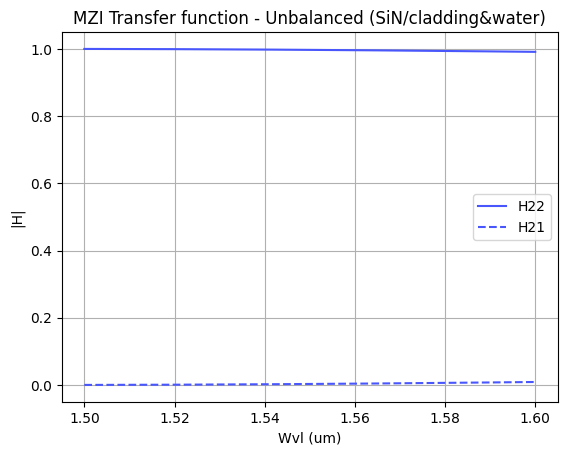

In [14]:
### Waveguides configuration ###

## Propagation parameters

## SOI cross-section ##
SOI = np.loadtxt('SOI-w450-h220-clad600.txt', skiprows=1, delimiter='\t')

#wvl = SOI[:, 0]
#neffu = SOI[:, 5] #balanced configuration // (neff TE mode)
#neffd = SOI[:, 3] #balanced configuration // (neff TE mode)

## SiN cross-section ##
SiN_clad = np.loadtxt('SiN-h300nm-w1000nm-Cladding.txt', skiprows=1, delimiter='\t')
SiN_wat = np.loadtxt('SiN-h300nm-w1000nm-Water.txt', skiprows=1, delimiter='\t')

wvl0 = SiN_clad[:, 0]
neffu0 = SiN_clad[:, 3] #balanced configuration // (neff TE mode)
neffd0 = SiN_wat[:, 3] #balanced configuration // (neff TE mode)

interp_neffu = interp1d(wvl0, neffu0, kind='cubic')  # Cubic interpolation for smoothness
interp_neffd = interp1d(wvl0, neffd0, kind='cubic')
wvl = np.linspace(wvl0.min(), wvl0.max(), 1000)
neffu = interp_neffu(wvl)
neffd = interp_neffd(wvl)

# Propagation loss
alphau = 0 #losless case [dB/um]
alphad = 0; #losless case [dB/um]
alphau_np = (jnp.log(10.0)/10.0) * alphau   # neper/um
alphad_np = (jnp.log(10.0)/10.0) * alphad   # neper/um

# Path length
Lu = 25; # um
Ld = 25; # um

betau = (2*jnp.pi/wvl)*neffu-1j*alphau_np
betad = (2*jnp.pi/wvl)*neffd-1j*alphad_np

Delta_phi_ud = betau*Lu - betad*Ld

### Couplers configuration ###
# Excess loss
gamma_a = 0; #null excess loss
gamma_b = 0; #null excess loss

# Coupling constant
K_a = np.full(wvl.shape, 0.5)
K_b = np.full(wvl.shape, 0.5)

# MZI transfer function (h22 & h21)

#  h_22(wvl)
h_22 = (np.sqrt((1 - gamma_a) * (1 - gamma_b)))*(np.exp(-1j * betad * Ld))*(( np.sqrt((1 - K_a) * (1 - K_b)) * np.exp(-1j * Delta_phi_ud))-(np.sqrt(K_a * K_b)))

#  h_21(wvl)
h_21 = (1j * np.sqrt((1 - gamma_a) * (1 - gamma_b)))*(np.exp(-1j * betad * Ld))*((np.sqrt(K_b * (1 - K_a)) * np.exp(-1j * Delta_phi_ud))+(np.sqrt(K_a * (1 - K_b))))

H21 = np.abs(h_21) ** 2
H22 = np.abs(h_22) ** 2

# Plot
color = cm.rainbow(np.linspace(0, 1, 10))

plt.plot(wvl, H22, linestyle='-', color=color[1], label='H22')
plt.plot(wvl, H21, linestyle='--', color=color[1], label='H21')
plt.xlabel('Wvl (um)')
plt.ylabel('|H|')
plt.title('MZI Transfer function - Unbalanced (SiN/cladding&water)')
plt.legend()
plt.grid(True)

plt.show()

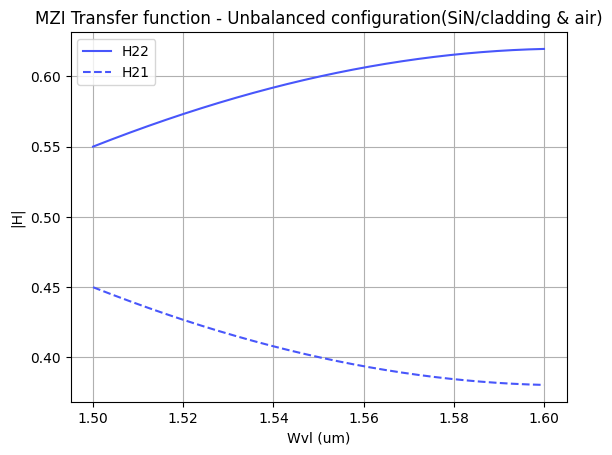

In [15]:
### Waveguides configuration ###

## Propagation parameters

## SOI cross-section ##
#SOI = np.loadtxt('SOI-w450-h220-clad600.txt', skiprows=1, delimiter='\t')

#wvl = SOI[:, 0]
#neffu = SOI[:, 3] #balanced configuration // (neff TE mode)
#neffd = SOI[:, 3] #balanced configuration // (neff TE mode)

## SiN cross-section ##
SiN_clad = np.loadtxt('SiN-h300nm-w1000nm-Cladding.txt', skiprows=1, delimiter='\t')
#SiN_wat = np.loadtxt('SiN-h300nm-w1000nm-Water.txt', skiprows=1, delimiter='\t')
SiN_air = np.loadtxt('SiN-h300nm-w1000nm-Air.txt', skiprows=1, delimiter='\t')

wvl0 = SiN_clad[:, 0]
neffu0 = SiN_clad[:, 3] #balanced configuration // (neff TE mode)
#neffd0 = SiN_wat[:, 3] #balanced configuration // (neff TE mode)
neffd0 = SiN_air[:, 3]

interp_neffu = interp1d(wvl0, neffu0, kind='cubic')  # Cubic interpolation for smoothness
interp_neffd = interp1d(wvl0, neffd0, kind='cubic')
wvl = np.linspace(wvl0.min(), wvl0.max(), 1000)
neffu = interp_neffu(wvl)
neffd = interp_neffd(wvl)

# Propagation loss
alphau = 0 #losless case [dB/um]
alphad = 0; #losless case [dB/um]
alphau_np = (jnp.log(10.0)/10.0) * alphau   # neper/um
alphad_np = (jnp.log(10.0)/10.0) * alphad   # neper/um

# Path length
Lu = 25; # um
Ld = 25; # um

betau = (2*jnp.pi/wvl)*neffu-1j*alphau_np
betad = (2*jnp.pi/wvl)*neffd-1j*alphad_np

Delta_phi_ud = betau*Lu - betad*Ld

### Couplers configuration ###
# Excess loss
gamma_a = 0; #null excess loss
gamma_b = 0; #null excess loss

# Coupling constant
K_a = np.full(wvl.shape, 0.5)
K_b = np.full(wvl.shape, 0.5)

# MZI transfer function (h22 & h21)

#  h_22(wvl)
h_22 = (np.sqrt((1 - gamma_a) * (1 - gamma_b)))*(np.exp(-1j * betad * Ld))*(( np.sqrt((1 - K_a) * (1 - K_b)) * np.exp(-1j * Delta_phi_ud))-(np.sqrt(K_a * K_b)))

#  h_21(wvl)
h_21 = (1j * np.sqrt((1 - gamma_a) * (1 - gamma_b)))*(np.exp(-1j * betad * Ld))*((np.sqrt(K_b * (1 - K_a)) * np.exp(-1j * Delta_phi_ud))+(np.sqrt(K_a * (1 - K_b))))

H21 = np.abs(h_21) ** 2
H22 = np.abs(h_22) ** 2

# Plot
color = cm.rainbow(np.linspace(0, 1, 10))

plt.plot(wvl, H22, linestyle='-', color=color[1], label='H22')
plt.plot(wvl, H21, linestyle='--', color=color[1], label='H21')
plt.xlabel('Wvl (um)')
plt.ylabel('|H|')
plt.title('MZI Transfer function - Unbalanced configuration(SiN/cladding & air)')
plt.legend()
plt.grid(True)

plt.show()

**Assesment 2.** Taking into account the n_{eff} values for the SOI cross-section, what would be the path difference ($\Delta L$ = $L_u$ - $L_d$) needed to obtain a Free Spectral Range of 40 nm? Introduce the obtained value in the model to check the MZI response. Hint: We assume 1550 nm as the central design wavelength ($\lambda _0$=1550 nm).

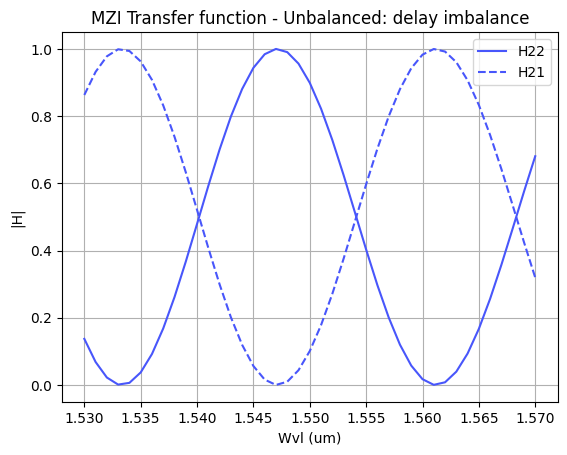

In [16]:
### Waveguides configuration ###

## Propagation parameters

## SOI cross-section ##
SOI = np.loadtxt('SOI-w450-h220-clad600.txt', skiprows=1, delimiter='\t')

wvl = SOI[:, 0]
neffu = SOI[:, 3] #balanced configuration // (neff TE mode)
neffd = SOI[:, 3] #balanced configuration // (neff TE mode)

## SiN cross-section ##
# SiN_clad = np.loadtxt('SiN-h300nm-w1000nm-Cladding.txt', skiprows=1, delimiter='\t')
# SiN_wat = np.loadtxt('SiN-h300nm-w1000nm-Water.txt', skiprows=1, delimiter='\t')

# wvl0 = SiN_clad[:, 0]
# neffu0 = SiN_clad[:, 3] #balanced configuration // (neff TE mode)
# neffd0 = SiN_wat[:, 3] #balanced configuration // (neff TE mode)

# interp_neffu = interp1d(wvl0, neffu0, kind='cubic')  # Cubic interpolation for smoothness
# interp_neffd = interp1d(wvl0, neffd0, kind='cubic')
# wvl = np.linspace(wvl0.min(), wvl0.max(), 1000)
# neffu = interp_neffu(wvl)
# neffd = interp_neffd(wvl)

# Propagation loss
alphau = 0 #losless case [dB/um]
alphad = 0; #losless case [dB/um]
alphau_np = (jnp.log(10.0)/10.0) * alphau   # neper/um
alphad_np = (jnp.log(10.0)/10.0) * alphad   # neper/um

# Path length
Lu = 25; # um
Ld = 5; # um

betau = (2*jnp.pi/wvl)*neffu-1j*alphau_np
betad = (2*jnp.pi/wvl)*neffd-1j*alphad_np

Delta_phi_ud = betau*Lu - betad*Ld

### Couplers configuration ###
# Excess loss
gamma_a = 0; #null excess loss
gamma_b = 0; #null excess loss

# Coupling constant
K_a = np.full(wvl.shape, 0.5)
K_b = np.full(wvl.shape, 0.5)

# MZI transfer function (h22 & h21)

#  h_22(wvl)
h_22 = (np.sqrt((1 - gamma_a) * (1 - gamma_b)))*(np.exp(-1j * betad * Ld))*(( np.sqrt((1 - K_a) * (1 - K_b)) * np.exp(-1j * Delta_phi_ud))-(np.sqrt(K_a * K_b)))

#  h_21(wvl)
h_21 = (1j * np.sqrt((1 - gamma_a) * (1 - gamma_b)))*(np.exp(-1j * betad * Ld))*((np.sqrt(K_b * (1 - K_a)) * np.exp(-1j * Delta_phi_ud))+(np.sqrt(K_a * (1 - K_b))))

H21 = np.abs(h_21) ** 2
H22 = np.abs(h_22) ** 2

# Plot
color = cm.rainbow(np.linspace(0, 1, 10))

plt.plot(wvl, H22, linestyle='-', color=color[1], label='H22')
plt.plot(wvl, H21, linestyle='--', color=color[1], label='H21')
plt.xlabel('Wvl (um)')
plt.ylabel('|H|')
plt.title('MZI Transfer function - Unbalanced: delay imbalance')
plt.legend()
plt.grid(True)

plt.show()

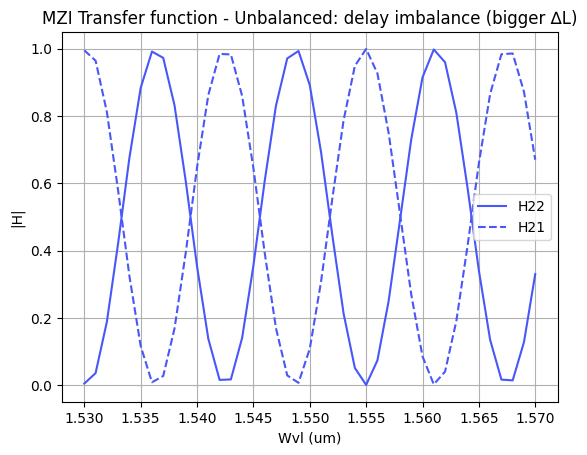

In [17]:
### Waveguides configuration ###

## Propagation parameters

## SOI cross-section ##
SOI = np.loadtxt('SOI-w450-h220-clad600.txt', skiprows=1, delimiter='\t')

wvl = SOI[:, 0]
neffu = SOI[:, 3] #balanced configuration // (neff TE mode)
neffd = SOI[:, 3] #balanced configuration // (neff TE mode)

## SiN cross-section ##
# SiN_clad = np.loadtxt('SiN-h300nm-w1000nm-Cladding.txt', skiprows=1, delimiter='\t')
# SiN_wat = np.loadtxt('SiN-h300nm-w1000nm-Water.txt', skiprows=1, delimiter='\t')

# wvl0 = SiN_clad[:, 0]
# neffu0 = SiN_clad[:, 3] #balanced configuration // (neff TE mode)
# neffd0 = SiN_wat[:, 3] #balanced configuration // (neff TE mode)

# interp_neffu = interp1d(wvl0, neffu0, kind='cubic')  # Cubic interpolation for smoothness
# interp_neffd = interp1d(wvl0, neffd0, kind='cubic')
# wvl = np.linspace(wvl0.min(), wvl0.max(), 1000)
# neffu = interp_neffu(wvl)
# neffd = interp_neffd(wvl)

# Propagation loss
alphau = 0 #losless case [dB/um]
alphad = 0; #losless case [dB/um]
alphau_np = (jnp.log(10.0)/10.0) * alphau   # neper/um
alphad_np = (jnp.log(10.0)/10.0) * alphad   # neper/um

# Path length
Lu = 50; # um
Ld = 5; # um

betau = (2*jnp.pi/wvl)*neffu-1j*alphau_np
betad = (2*jnp.pi/wvl)*neffd-1j*alphad_np

Delta_phi_ud = betau*Lu - betad*Ld

### Couplers configuration ###
# Excess loss
gamma_a = 0; #null excess loss
gamma_b = 0; #null excess loss

# Coupling constant
K_a = np.full(wvl.shape, 0.5)
K_b = np.full(wvl.shape, 0.5)

# MZI transfer function (h22 & h21)

#  h_22(wvl)
h_22 = (np.sqrt((1 - gamma_a) * (1 - gamma_b)))*(np.exp(-1j * betad * Ld))*(( np.sqrt((1 - K_a) * (1 - K_b)) * np.exp(-1j * Delta_phi_ud))-(np.sqrt(K_a * K_b)))

#  h_21(wvl)
h_21 = (1j * np.sqrt((1 - gamma_a) * (1 - gamma_b)))*(np.exp(-1j * betad * Ld))*((np.sqrt(K_b * (1 - K_a)) * np.exp(-1j * Delta_phi_ud))+(np.sqrt(K_a * (1 - K_b))))

H21 = np.abs(h_21) ** 2
H22 = np.abs(h_22) ** 2

# Plot
color = cm.rainbow(np.linspace(0, 1, 10))

plt.plot(wvl, H22, linestyle='-', color=color[1], label='H22')
plt.plot(wvl, H21, linestyle='--', color=color[1], label='H21')
plt.xlabel('Wvl (um)')
plt.ylabel('|H|')
plt.title('MZI Transfer function - Unbalanced: delay imbalance (bigger ∆L)')
plt.legend()
plt.grid(True)

plt.show()

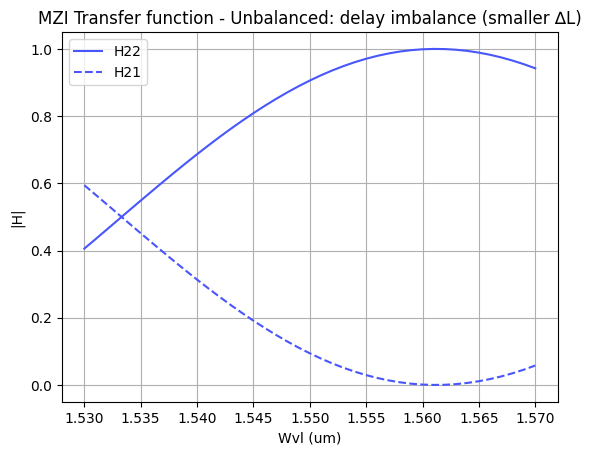

In [18]:
### Waveguides configuration ###

## Propagation parameters

## SOI cross-section ##
SOI = np.loadtxt('SOI-w450-h220-clad600.txt', skiprows=1, delimiter='\t')

wvl = SOI[:, 0]
neffu = SOI[:, 3] #balanced configuration // (neff TE mode)
neffd = SOI[:, 3] #balanced configuration // (neff TE mode)

## SiN cross-section ##
# SiN_clad = np.loadtxt('SiN-h300nm-w1000nm-Cladding.txt', skiprows=1, delimiter='\t')
# SiN_wat = np.loadtxt('SiN-h300nm-w1000nm-Water.txt', skiprows=1, delimiter='\t')

# wvl0 = SiN_clad[:, 0]
# neffu0 = SiN_clad[:, 3] #balanced configuration // (neff TE mode)
# neffd0 = SiN_wat[:, 3] #balanced configuration // (neff TE mode)

# interp_neffu = interp1d(wvl0, neffu0, kind='cubic')  # Cubic interpolation for smoothness
# interp_neffd = interp1d(wvl0, neffd0, kind='cubic')
# wvl = np.linspace(wvl0.min(), wvl0.max(), 1000)
# neffu = interp_neffu(wvl)
# neffd = interp_neffd(wvl)

# Propagation loss
alphau = 0 #losless case [dB/um]
alphad = 0; #losless case [dB/um]
alphau_np = (jnp.log(10.0)/10.0) * alphau   # neper/um
alphad_np = (jnp.log(10.0)/10.0) * alphad   # neper/um

# Path length
Lu = 25; # um
Ld = 20; # um

betau = (2*jnp.pi/wvl)*neffu-1j*alphau_np
betad = (2*jnp.pi/wvl)*neffd-1j*alphad_np

Delta_phi_ud = betau*Lu - betad*Ld

### Couplers configuration ###
# Excess loss
gamma_a = 0; #null excess loss
gamma_b = 0; #null excess loss

# Coupling constant
K_a = np.full(wvl.shape, 0.5)
K_b = np.full(wvl.shape, 0.5)

# MZI transfer function (h22 & h21)

#  h_22(wvl)
h_22 = (np.sqrt((1 - gamma_a) * (1 - gamma_b)))*(np.exp(-1j * betad * Ld))*(( np.sqrt((1 - K_a) * (1 - K_b)) * np.exp(-1j * Delta_phi_ud))-(np.sqrt(K_a * K_b)))

#  h_21(wvl)
h_21 = (1j * np.sqrt((1 - gamma_a) * (1 - gamma_b)))*(np.exp(-1j * betad * Ld))*((np.sqrt(K_b * (1 - K_a)) * np.exp(-1j * Delta_phi_ud))+(np.sqrt(K_a * (1 - K_b))))

H21 = np.abs(h_21) ** 2
H22 = np.abs(h_22) ** 2

# Plot
color = cm.rainbow(np.linspace(0, 1, 10))

plt.plot(wvl, H22, linestyle='-', color=color[1], label='H22')
plt.plot(wvl, H21, linestyle='--', color=color[1], label='H21')
plt.xlabel('Wvl (um)')
plt.ylabel('|H|')
plt.title('MZI Transfer function - Unbalanced: delay imbalance (smaller ∆L)')
plt.legend()
plt.grid(True)

plt.show()

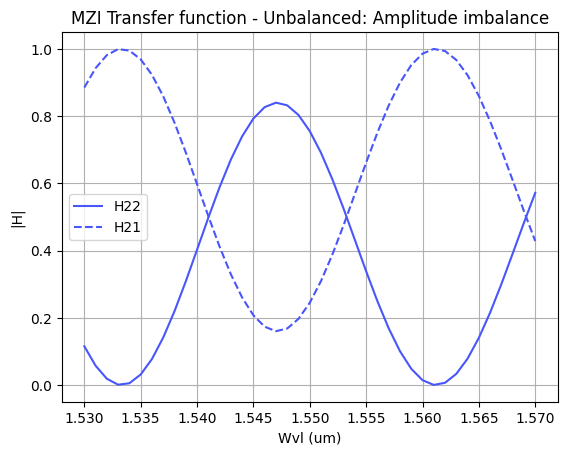

In [19]:
### Waveguides configuration ###

## Propagation parameters

## SOI cross-section ##
SOI = np.loadtxt('SOI-w450-h220-clad600.txt', skiprows=1, delimiter='\t')

wvl = SOI[:, 0]
neffu = SOI[:, 3] #balanced configuration // (neff TE mode)
neffd = SOI[:, 3] #balanced configuration // (neff TE mode)

## SiN cross-section ##
# SiN_clad = np.loadtxt('SiN-h300nm-w1000nm-Cladding.txt', skiprows=1, delimiter='\t')
# SiN_wat = np.loadtxt('SiN-h300nm-w1000nm-Water.txt', skiprows=1, delimiter='\t')

# wvl0 = SiN_clad[:, 0]
# neffu0 = SiN_clad[:, 3] #balanced configuration // (neff TE mode)
# neffd0 = SiN_wat[:, 3] #balanced configuration // (neff TE mode)

# interp_neffu = interp1d(wvl0, neffu0, kind='cubic')  # Cubic interpolation for smoothness
# interp_neffd = interp1d(wvl0, neffd0, kind='cubic')
# wvl = np.linspace(wvl0.min(), wvl0.max(), 1000)
# neffu = interp_neffu(wvl)
# neffd = interp_neffd(wvl)

# Propagation loss
alphau = 0 #losless case [dB/um]
alphad = 0; #losless case [dB/um]
alphau_np = (jnp.log(10.0)/10.0) * alphau   # neper/um
alphad_np = (jnp.log(10.0)/10.0) * alphad   # neper/um

# Path length
Lu = 25; # um
Ld = 5; # um

betau = (2*jnp.pi/wvl)*neffu-1j*alphau_np
betad = (2*jnp.pi/wvl)*neffd-1j*alphad_np

Delta_phi_ud = betau*Lu - betad*Ld

### Couplers configuration ###
# Excess loss
gamma_a = 0; #null excess loss
gamma_b = 0; #null excess loss

# Coupling constant
K_a = np.full(wvl.shape, 0.7)
K_b = np.full(wvl.shape, 0.3)

# MZI transfer function (h22 & h21)

#  h_22(wvl)
h_22 = (np.sqrt((1 - gamma_a) * (1 - gamma_b)))*(np.exp(-1j * betad * Ld))*(( np.sqrt((1 - K_a) * (1 - K_b)) * np.exp(-1j * Delta_phi_ud))-(np.sqrt(K_a * K_b)))

#  h_21(wvl)
h_21 = (1j * np.sqrt((1 - gamma_a) * (1 - gamma_b)))*(np.exp(-1j * betad * Ld))*((np.sqrt(K_b * (1 - K_a)) * np.exp(-1j * Delta_phi_ud))+(np.sqrt(K_a * (1 - K_b))))

H21 = np.abs(h_21) ** 2
H22 = np.abs(h_22) ** 2

# Plot
color = cm.rainbow(np.linspace(0, 1, 10))

plt.plot(wvl, H22, linestyle='-', color=color[1], label='H22')
plt.plot(wvl, H21, linestyle='--', color=color[1], label='H21')
plt.xlabel('Wvl (um)')
plt.ylabel('|H|')
plt.title('MZI Transfer function - Unbalanced: Amplitude imbalance')
plt.legend()
plt.grid(True)

plt.show()

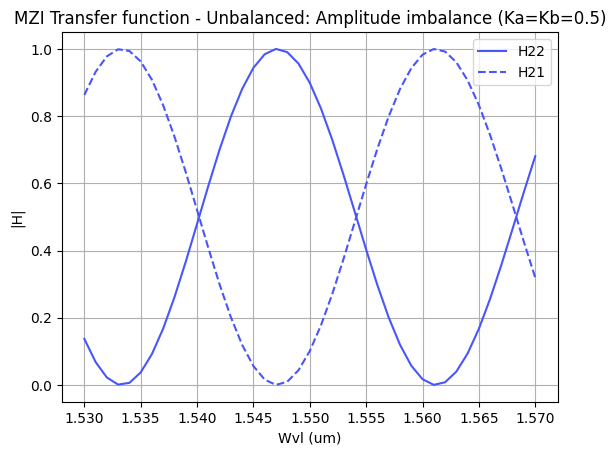

In [20]:
### Waveguides configuration ###

## Propagation parameters

## SOI cross-section ##
SOI = np.loadtxt('SOI-w450-h220-clad600.txt', skiprows=1, delimiter='\t')

wvl = SOI[:, 0]
neffu = SOI[:, 3] #balanced configuration // (neff TE mode)
neffd = SOI[:, 3] #balanced configuration // (neff TE mode)

## SiN cross-section ##
# SiN_clad = np.loadtxt('SiN-h300nm-w1000nm-Cladding.txt', skiprows=1, delimiter='\t')
# SiN_wat = np.loadtxt('SiN-h300nm-w1000nm-Water.txt', skiprows=1, delimiter='\t')

# wvl0 = SiN_clad[:, 0]
# neffu0 = SiN_clad[:, 3] #balanced configuration // (neff TE mode)
# neffd0 = SiN_wat[:, 3] #balanced configuration // (neff TE mode)

# interp_neffu = interp1d(wvl0, neffu0, kind='cubic')  # Cubic interpolation for smoothness
# interp_neffd = interp1d(wvl0, neffd0, kind='cubic')
# wvl = np.linspace(wvl0.min(), wvl0.max(), 1000)
# neffu = interp_neffu(wvl)
# neffd = interp_neffd(wvl)

# Propagation loss
alphau = 0 #losless case [dB/um]
alphad = 0; #losless case [dB/um]
alphau_np = (jnp.log(10.0)/10.0) * alphau   # neper/um
alphad_np = (jnp.log(10.0)/10.0) * alphad   # neper/um

# Path length
Lu = 25; # um
Ld = 5; # um

betau = (2*jnp.pi/wvl)*neffu-1j*alphau_np
betad = (2*jnp.pi/wvl)*neffd-1j*alphad_np

Delta_phi_ud = betau*Lu - betad*Ld

### Couplers configuration ###
# Excess loss
gamma_a = 0; #null excess loss
gamma_b = 0; #null excess loss

# Coupling constant
K_a = np.full(wvl.shape, 0.5)
K_b = np.full(wvl.shape, 0.5)

# MZI transfer function (h22 & h21)

#  h_22(wvl)
h_22 = (np.sqrt((1 - gamma_a) * (1 - gamma_b)))*(np.exp(-1j * betad * Ld))*(( np.sqrt((1 - K_a) * (1 - K_b)) * np.exp(-1j * Delta_phi_ud))-(np.sqrt(K_a * K_b)))

#  h_21(wvl)
h_21 = (1j * np.sqrt((1 - gamma_a) * (1 - gamma_b)))*(np.exp(-1j * betad * Ld))*((np.sqrt(K_b * (1 - K_a)) * np.exp(-1j * Delta_phi_ud))+(np.sqrt(K_a * (1 - K_b))))

H21 = np.abs(h_21) ** 2
H22 = np.abs(h_22) ** 2

# Plot
color = cm.rainbow(np.linspace(0, 1, 10))

plt.plot(wvl, H22, linestyle='-', color=color[1], label='H22')
plt.plot(wvl, H21, linestyle='--', color=color[1], label='H21')
plt.xlabel('Wvl (um)')
plt.ylabel('|H|')
plt.title('MZI Transfer function - Unbalanced: Amplitude imbalance (Ka=Kb=0.5)')
plt.legend()
plt.grid(True)

plt.show()

**Assesment 2.** Taking into account the n_{eff} values for the SOI cross-section, what would be the path difference ($\Delta L$ = $L_u$ - $L_d$) needed to obtain a Free Spectral Range of 40 nm? Introduce the obtained value in the model to check the MZI response. Hint: We assume 1550 nm as the central design wavelength ($\lambda _0$=1550 nm).

In [21]:

wvl = SOI[:, 0]
neffu = SOI[:, 3] 
neffd = SOI[:, 3]
ng = neffu - wvl*np.gradient(neffu, wvl)
FSR = 0.04




L_incr = (wvl**2)/(ng*FSR)
L_incr_sel = L_incr[20] #Longitud para la lambda = 1.55 um
Lu = 25
print(f'∆L chosen: {L_incr_sel}')
print(f'Ld necessary to obtain a FSR de 40 nm: {Lu - L_incr_sel} ')

∆L chosen: 13.989919105949546
Ld necessary to obtain a FSR de 40 nm: 11.010080894050454 


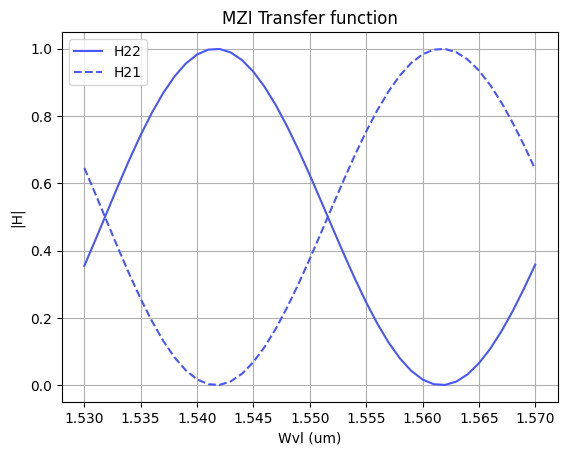

In [22]:
### Waveguides configuration ###

## Propagation parameters

## SOI cross-section ##
SOI = np.loadtxt('SOI-w450-h220-clad600.txt', skiprows=1, delimiter='\t')

wvl = SOI[:, 0]
neffu = SOI[:, 3] #balanced configuration // (neff TE mode)
neffd = SOI[:, 3] #balanced configuration // (neff TE mode)


# Propagation loss
alphau = 0 #losless case [dB/um]
alphad = 0; #losless case [dB/um]
alphau_np = (jnp.log(10.0)/10.0) * alphau   # neper/um
alphad_np = (jnp.log(10.0)/10.0) * alphad   # neper/um

# Path length
Lu = 25; # um
Ld = 10.992; # um

betau = (2*jnp.pi/wvl)*neffu-1j*alphau_np
betad = (2*jnp.pi/wvl)*neffd-1j*alphad_np

Delta_phi_ud = betau*Lu - betad*Ld

### Couplers configuration ###
# Excess loss
gamma_a = 0; #null excess loss
gamma_b = 0; #null excess loss

# Coupling constant
K_a = np.full(wvl.shape, 0.5)
K_b = np.full(wvl.shape, 0.5)

# MZI transfer function (h22 & h21)

#  h_22(wvl)
h_22 = (np.sqrt((1 - gamma_a) * (1 - gamma_b)))*(np.exp(-1j * betad * Ld))*(( np.sqrt((1 - K_a) * (1 - K_b)) * np.exp(-1j * Delta_phi_ud))-(np.sqrt(K_a * K_b)))

#  h_21(wvl)
h_21 = (1j * np.sqrt((1 - gamma_a) * (1 - gamma_b)))*(np.exp(-1j * betad * Ld))*((np.sqrt(K_b * (1 - K_a)) * np.exp(-1j * Delta_phi_ud))+(np.sqrt(K_a * (1 - K_b))))

H21 = np.abs(h_21) ** 2
H22 = np.abs(h_22) ** 2

# Plot
color = cm.rainbow(np.linspace(0, 1, 10))

plt.plot(wvl, H22, linestyle='-', color=color[1], label='H22')
plt.plot(wvl, H21, linestyle='--', color=color[1], label='H21')
plt.xlabel('Wvl (um)')
plt.ylabel('|H|')
plt.title('MZI Transfer function')
plt.legend()
plt.grid(True)

plt.show()

## 2. MZI simulation implemented with SAX
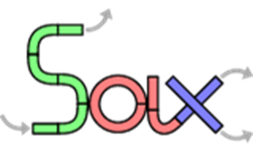

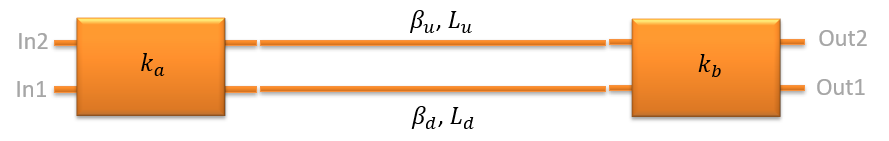


### 2.1 Components S matrix


In [23]:
# Waveguide Model

def waveguide(wl=1.55, neff=1.6072, length=10.0, loss=0.0) -> sax.SDict:
    phase = 2 * jnp.pi * neff * length / wl
    transmission = 10 ** (-loss * length / 20) * jnp.exp(1j * phase) # loss(dB/um)
    wg_dict = sax.reciprocal(
        {
            ("in0", "out0"): transmission,
        }
    )
    return wg_dict


# Coupler Model

def coupler(coupling=0.5) -> sax.SDict:
    kappa = coupling**0.5
    tau = (1 - coupling) ** 0.5
    coupler_dict = sax.reciprocal(
        {
            ("in0", "out0"): tau,
            ("in0", "out1"): kappa * np.exp(-1j * np.pi / 2.0),
            ("in1", "out0"): kappa * np.exp(-1j * np.pi / 2.0),
            ("in1", "out1"): tau,
        }
    )
    return coupler_dict

### 2.2 MZI SAX Circuit Model

In [24]:
# MZI

mzi, info = sax.circuit(
    netlist={
        "instances": {
            "coup_a": "coupler",
            "wvg_u": "waveguide",
            "wvg_d": "waveguide",
            "coup_b": "coupler",
        },
        "connections": {
            "coup_a,out0": "wvg_d,in0",
            "wvg_d,out0": "coup_b,in0",
            "coup_a,out1": "wvg_u,in0",
            "wvg_u,out0": "coup_b,in1",
        },
        "ports": {
            "in0": "coup_a,in0",
            "in1": "coup_a,in1",
            "out0": "coup_b,out0",
            "out1": "coup_b,out1",
        },
    },
    models={
        "coupler": coupler,
        "waveguide": waveguide,
    },
)


### 2.3. MZI Modeling
**Assesment 3**: Now, we are going to implement the design parameters in the MZI model developed in SAX and compare the response obtained with that simulated by mathematical formulation.

This will help us to identify any error in the definition of the SAX model single components.

In order to implement the SAX model, take as example the following lines:

    mzi_test = mzi(wl=wl,
                coup_a = ...
                wvg_d={"length": l_d, "neff": ...},
                wvg_u={"length": l_u, "neff": ...},
                coup_b = ... )

    H00 = mzi_test["in0", "out0"]

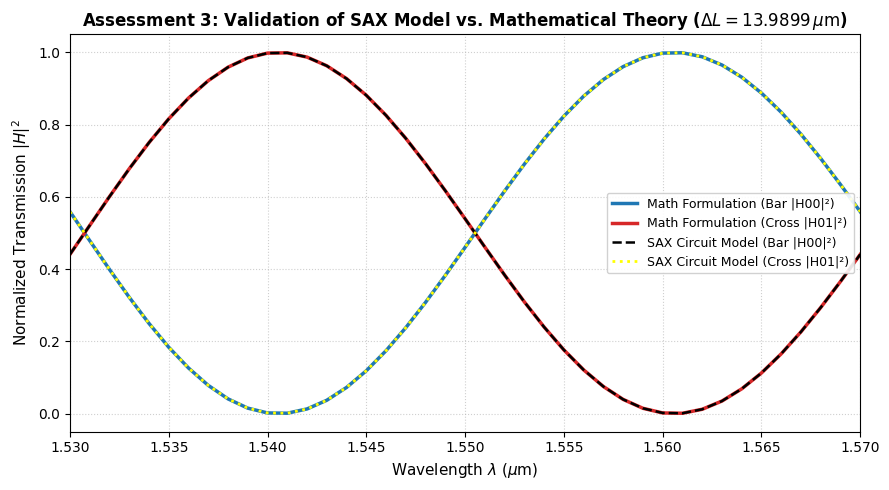

In [31]:
import matplotlib.pyplot as plt
import numpy as np

# ==============================================================================
# 1. Cargar datos del SOI y definir parámetros de diseño (Assessment 2)
# ==============================================================================
SOI = np.loadtxt('SOI-w450-h220-clad600.txt', skiprows=1, delimiter='\t')
wvl = SOI[:, 0]  # Wavelength array (µm)
neff = SOI[:, 3]  # Fundamental TE effective index

# Parámetros del diseño calculado en Assessment 2 (FSR = 40 nm)
delta_L = 13.9899  # µm
Ld = 25.0  # Base length (µm)
Lu = Ld + delta_L  # 38.9899 µm

# Acopladores 3-dB ideales (50:50) y pérdidas nulas
K_a = np.full(wvl.shape, 0.5)
K_b = np.full(wvl.shape, 0.5)
alphau = 0.0
alphad = 0.0

# ==============================================================================
# 2. Formulación Matemática / Analítica (Teoría)
# ==============================================================================
# Desfase acumulado entre los dos brazos:
delta_phi = (2.0 * np.pi / wvl) * neff * (Lu - Ld)

# Transmisión analítica para acopladores ideales de 3 dB:
# T_bar = cos^2(delta_phi / 2), T_cross = sin^2(delta_phi / 2)
T_bar_math = np.cos(delta_phi / 2.0) ** 2
T_cross_math = np.sin(delta_phi / 2.0) ** 2

# ==============================================================================
# 3. Simulación mediante el modelo de circuito en SAX
# ==============================================================================
mzi_test = mzi(
    wl=wvl,
    coup_a={'coupling': K_a},
    wvg_u={'wl': wvl, 'neff': neff, 'length': Lu, 'loss': alphau},
    wvg_d={'wl': wvl, 'neff': neff, 'length': Ld, 'loss': alphad},
    coup_b={'coupling': K_b},
)

# Extracción de parámetros S en SAX (inyectando por in0)
h00 = mzi_test['in0', 'out0']  # Through / Bar port
h01 = mzi_test['in0', 'out1']  # Cross port

T_bar_sax = np.abs(h00) ** 2
T_cross_sax = np.abs(h01) ** 2

# ==============================================================================
# 4. Gráfica comparativa: Formulación Matemática vs. SAX
# ==============================================================================
plt.figure(figsize=(9, 5))

# Curvas teóricas (líneas continuas más gruesas)
plt.plot(
    wvl,
    T_bar_math,
    '-',
    color='#1f77b4',
    lw=2.5,
    label='Math Formulation (Bar |H00|²)',
)
plt.plot(
    wvl,
    T_cross_math,
    '-',
    color='#d62728',
    lw=2.5,
    label='Math Formulation (Cross |H01|²)',
)

# Simulación SAX (línea discontinua / puntos para verificar coincidencia exacta)
plt.plot(
    wvl,
    T_bar_sax,
    '--',
    color='black',
    lw=1.8,
    label='SAX Circuit Model (Bar |H00|²)',
)
plt.plot(
    wvl,
    T_cross_sax,
    ':',
    color='yellow',
    lw=2.0,
    label='SAX Circuit Model (Cross |H01|²)',
)

plt.xlabel(r'Wavelength $\lambda$ ($\mu\mathrm{m}$)', fontsize=11)
plt.ylabel(r'Normalized Transmission $|H|^2$', fontsize=11)
plt.title(
    r'Assessment 3: Validation of SAX Model vs. Mathematical Theory ($\Delta L = 13.9899\,\mu\mathrm{m}$)',
    fontsize=12,
    weight='bold',
)
plt.xlim(wvl.min(), wvl.max())
plt.ylim(-0.05, 1.05)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='center right', fontsize=9, framealpha=0.9)
plt.tight_layout()
plt.show()

**EXTRA ASSESSMENTS**

**Assessment 4.** Designing an MZI for filtering at a specific wavelength. Calculate and adjust the arm lengths to configure the MZI to have a maximum transmission at 1550 nm.



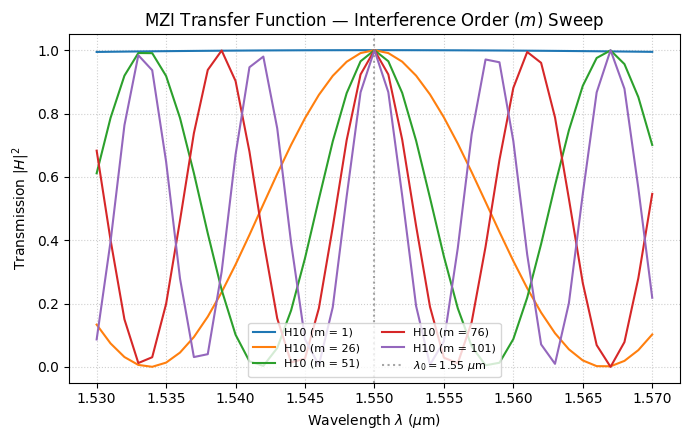

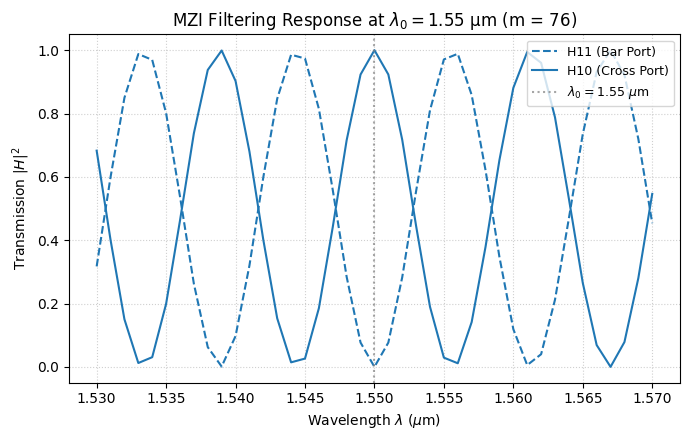

In [29]:
import matplotlib.pyplot as plt
import numpy as np

# Load SOI effective index data
SOI = np.loadtxt("SOI-w450-h220-clad600.txt", skiprows=1, delimiter="\t")
wvl = SOI[:, 0]  # Wavelength array (µm)
wvl_0 = SOI[20, 0]  # Central wavelength: 1.55 µm
neffu = SOI[:, 3]  # Fundamental TE effective index
neffd = SOI[:, 3]

# Ideal 3-dB couplers (50:50 power splitting)
K_a = np.full(wvl.shape, 0.5)
K_b = np.full(wvl.shape, 0.5)

# Losses (lossless baseline)
alphau = 0.0  # dB/µm
alphad = 0.0  # dB/µm

# Base physical length (µm)
L_base = 25.0

# ==============================================================================
# 1. Sweep interference order m
# ==============================================================================
plt.figure(figsize=(7, 4.5))

for m in [1, 26, 51, 76, 101]:
    L_incr = m * (wvl_0 / neffu[20])
    Ld = L_base
    Lu = L_base + L_incr

    mzi_test = mzi(
        wl=wvl,
        coup_a={"coupling": K_a},
        wvg_u={"wl": wvl, "neff": neffu, "length": Lu, "loss": alphau},
        wvg_d={"wl": wvl, "neff": neffd, "length": Ld, "loss": alphad},
        coup_b={"coupling": K_b},
    )

    h10 = mzi_test["in1", "out0"]
    H10 = np.abs(h10) ** 2
    plt.plot(wvl, H10, linestyle="-", label=f"H10 (m = {m})")

plt.xlabel(r"Wavelength $\lambda$ ($\mu\mathrm{m}$)")
plt.ylabel(r"Transmission $|H|^2$")
plt.title("MZI Transfer Function — Interference Order ($m$) Sweep")
plt.axvline(
    x=1.55,
    color="gray",
    linestyle=":",
    alpha=0.7,
    label=r"$\lambda_0 = 1.55\ \mu\text{m}$",
)
plt.legend(ncol=2, fontsize=8, loc="lower center")
plt.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()

# ==============================================================================
# 2. Selected design: m = 76
# ==============================================================================
m_selected = 76
L_incr_selected = m_selected * (wvl_0 / neffu[20])
Ld = L_base
Lu = L_base + L_incr_selected

mzi_selected = mzi(
    wl=wvl,
    coup_a={"coupling": K_a},
    wvg_u={"wl": wvl, "neff": neffu, "length": Lu, "loss": alphau},
    wvg_d={"wl": wvl, "neff": neffd, "length": Ld, "loss": alphad},
    coup_b={"coupling": K_b},
)

H11 = np.abs(mzi_selected["in1", "out1"]) ** 2
H10 = np.abs(mzi_selected["in1", "out0"]) ** 2

plt.figure(figsize=(7, 4.5))
plt.plot(wvl, H11, linestyle="--", color="tab:blue", label="H11 (Bar Port)")
plt.plot(wvl, H10, linestyle="-", color="tab:blue", label="H10 (Cross Port)")
plt.axvline(
    x=1.55,
    color="gray",
    linestyle=":",
    alpha=0.7,
    label=r"$\lambda_0 = 1.55\ \mu\text{m}$",
)

plt.xlabel(r"Wavelength $\lambda$ ($\mu\mathrm{m}$)")
plt.ylabel(r"Transmission $|H|^2$")
plt.title(f"MZI Filtering Response at $\\lambda_0 = 1.55$ µm (m = {m_selected})")
plt.legend(fontsize=9, loc="upper right")
plt.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()

**Assessment 5.** Let's see how the response of the MZI variates with the effective index. Vary the effective index of one of the arms and analyze how the spectrum shifts. To do this, you can use the data provided in the .txt files entitled ‘SiN’.
Can you give an example of an application where this configuration is used?



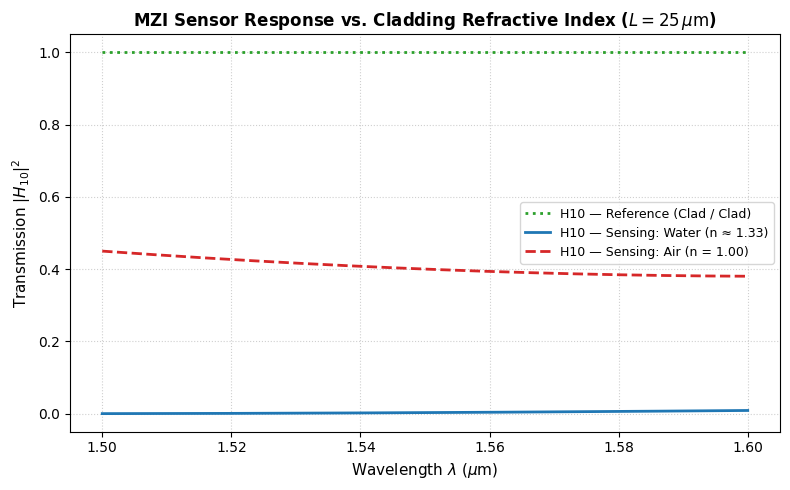

In [30]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import interp1d

# ==============================================================================
# 1. Cargar datos de la guía de SiN con diferentes recubrimientos
# ==============================================================================
SiN_clad = np.loadtxt(
    'SiN-h300nm-w1000nm-Cladding.txt', skiprows=1, delimiter='\t'
)
SiN_wat = np.loadtxt(
    'SiN-h300nm-w1000nm-Water.txt', skiprows=1, delimiter='\t'
)
SiN_air = np.loadtxt('SiN-h300nm-w1000nm-Air.txt', skiprows=1, delimiter='\t')

wvl0 = SiN_clad[:, 0]
neff_clad_raw = SiN_clad[:, 3]  # SiO2 cladding (referencia)
neff_wat_raw = SiN_wat[:, 3]  # Agua (n ≈ 1.33)
neff_air_raw = SiN_air[:, 3]  # Aire (n = 1.0)

# Interpolación cúbica sobre una rejilla densa
wvl = np.linspace(wvl0.min(), wvl0.max(), 1000)
neff_clad = interp1d(wvl0, neff_clad_raw, kind='cubic')(wvl)
neff_wat = interp1d(wvl0, neff_wat_raw, kind='cubic')(wvl)
neff_air = interp1d(wvl0, neff_air_raw, kind='cubic')(wvl)

# Acopladores 3-dB ideales y pérdidas nulas
K_a = np.full(wvl.shape, 0.5)
K_b = np.full(wvl.shape, 0.5)
alphau, alphad = 0.0, 0.0

# Longitud física de interacción (µm)
# Nota: L = 25 µm muestra modulación en intensidad; si aumentas L (ej. 150 µm) verás franjas completas
L_sense = 25.0

# ==============================================================================
# 2. Simulación de los 3 escenarios
# ==============================================================================
scenarios = [
    {
        'label': 'Reference (Clad / Clad)',
        'neff_d': neff_clad,
        'color': '#2ca02c',
        'ls': ':',
    },
    {
        'label': 'Sensing: Water (n ≈ 1.33)',
        'neff_d': neff_wat,
        'color': '#1f77b4',
        'ls': '-',
    },
    {
        'label': 'Sensing: Air (n = 1.00)',
        'neff_d': neff_air,
        'color': '#d62728',
        'ls': '--',
    },
]

plt.figure(figsize=(8, 5))

for sc in scenarios:
    mzi_sim = mzi(
        wl=wvl,
        coup_a={'coupling': K_a},
        wvg_u={
            'wl': wvl,
            'neff': neff_clad,
            'length': L_sense,
            'loss': alphau,
        },
        wvg_d={'wl': wvl, 'neff': sc['neff_d'], 'length': L_sense, 'loss': alphad},
        coup_b={'coupling': K_b},
    )

    # Puerto de transmisión cruzada H10
    H10 = np.abs(mzi_sim['in1', 'out0']) ** 2
    plt.plot(
        wvl,
        H10,
        label=f"H10 — {sc['label']}",
        color=sc['color'],
        linestyle=sc['ls'],
        lw=2.0,
    )

plt.xlabel(r'Wavelength $\lambda$ ($\mu\mathrm{m}$)', fontsize=11)
plt.ylabel(r'Transmission $|H_{10}|^2$', fontsize=11)
plt.title(
    r'MZI Sensor Response vs. Cladding Refractive Index ($L = 25\,\mu\mathrm{m}$)',
    fontsize=12,
    weight='bold',
)
plt.ylim(-0.05, 1.05)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=9, loc='center right')
plt.tight_layout()
plt.show()

**Advanced level assessment.** Explore how cascading two MZIs affects the transmission spectrum. To do so, design a system in which two MZIs are cascaded. Simulate and observe the spectrum, explaining how the transmission peaks behave.

<>:138: SyntaxWarning: invalid escape sequence '\m'
<>:161: SyntaxWarning: invalid escape sequence '\m'
<>:138: SyntaxWarning: invalid escape sequence '\m'
<>:161: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_1950/2344417821.py:138: SyntaxWarning: invalid escape sequence '\m'
  ax1.set_xlabel("Wavelength ($\mu$m)")
/tmp/ipykernel_1950/2344417821.py:161: SyntaxWarning: invalid escape sequence '\m'
  ax2.set_xlabel("Wavelength ($\mu$m)")


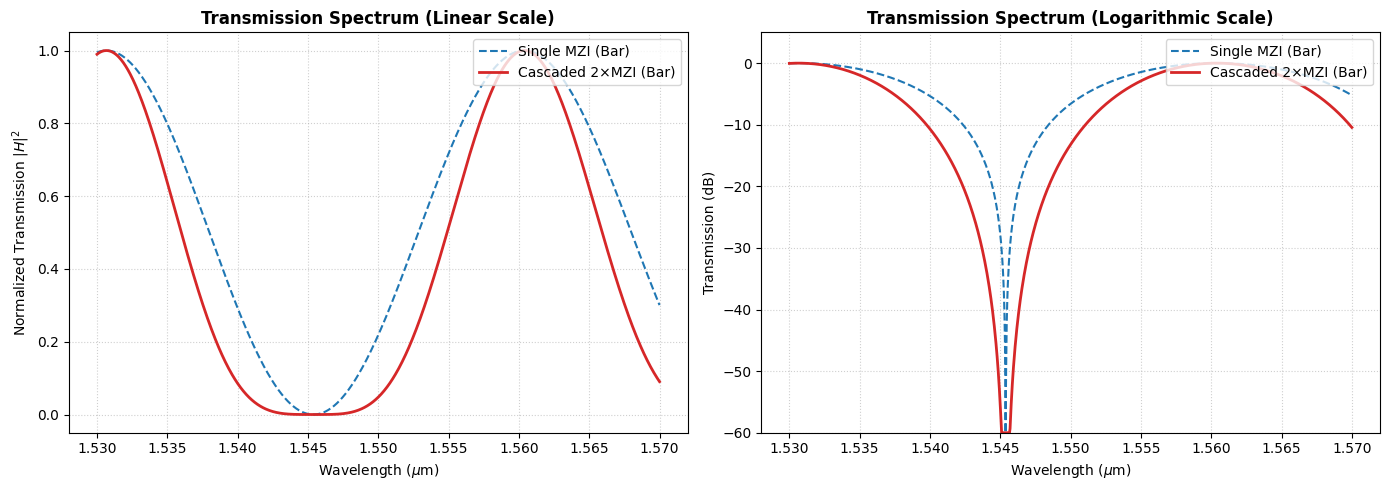

In [ ]:
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import sax

# ==============================================================================
# 1. Basic components
# ==============================================================================


def waveguide(wl=1.55, neff=1.6072, length=10.0, loss=0.0) -> sax.SDict:
    """Modelo de guía de onda con retardo de fase y pérdidas de propagación."""
    phase = 2 * jnp.pi * neff * length / wl
    transmission = 10 ** (-loss * length / 20.0) * jnp.exp(1j * phase)
    return sax.reciprocal({("in0", "out0"): transmission})


def coupler(coupling=0.5) -> sax.SDict:
    """Modelo de acoplador direccional simétrico 2x2 (3 dB por defecto)."""
    kappa = coupling**0.5
    tau = (1.0 - coupling) ** 0.5
    return sax.reciprocal(
        {
            ("in0", "out0"): tau,
            ("in0", "out1"): -1j * kappa,
            ("in1", "out0"): -1j * kappa,
            ("in1", "out1"): tau,
        }
    )


# ==============================================================================
# 2. SUBCIRCUIT: INDIVIDUAL MZI
# ==============================================================================

mzi_sub, _ = sax.circuit(
    netlist={
        "instances": {
            "coup_a": "coupler",
            "wvg_u": "waveguide",
            "wvg_d": "waveguide",
            "coup_b": "coupler",
        },
        "connections": {
            "coup_a,out0": "wvg_d,in0",
            "wvg_d,out0": "coup_b,in0",
            "coup_a,out1": "wvg_u,in0",
            "wvg_u,out0": "coup_b,in1",
        },
        "ports": {
            "in0": "coup_a,in0",
            "in1": "coup_a,in1",
            "out0": "coup_b,out0",  # Bar port
            "out1": "coup_b,out1",  # Cross port
        },
    },
    models={
        "coupler": coupler,
        "waveguide": waveguide,
    },
)

# ==============================================================================
# 3. cascade circuit: 2 MZIs 
# ==============================================================================

cascaded_mzi, _ = sax.circuit(
    netlist={
        "instances": {
            "mzi1": "mzi_model",
            "mzi2": "mzi_model",
        },
        "connections": {
            # Conectamos la salida Bar del primer MZI a la entrada del segundo MZI
            "mzi1,out0": "mzi2,in0",
        },
        "ports": {
            "in0": "mzi1,in0",
            "out0": "mzi2,out0",  # Bar final
            "out1": "mzi2,out1",  # Cross final
        },
    },
    models={
        "mzi_model": mzi_sub,
    },
)

# ==============================================================================
# 4. spectral simulation
# ==============================================================================

# Barrido espectral en banda C (1530 nm a 1570 nm)
wl = jnp.linspace(1.53, 1.57, 1000)

# Parámetros geométricos: Delta_L = 50 µm para cada MZI
L_down = 50.0  # µm
delta_L = 50.0  # µm
L_up = L_down + delta_L

params_mzi = {
    "wvg_u": {"length": L_up},
    "wvg_d": {"length": L_down},
    "coup_a": {"coupling": 0.5},
    "coup_b": {"coupling": 0.5},
}

# 1. Simulación de 1 solo MZI (referencia)
s_single = mzi_sub(wl=wl, **params_mzi)
t_single_bar = jnp.abs(s_single[("in0", "out0")]) ** 2
t_single_cross = jnp.abs(s_single[("in0", "out1")]) ** 2

# 2. Simulación de 2 MZIs en cascada idénticos
s_cascaded = cascaded_mzi(
    wl=wl,
    mzi1=params_mzi,
    mzi2=params_mzi,
)
t_cascaded_bar = jnp.abs(s_cascaded[("in0", "out0")]) ** 2
t_cascaded_cross = jnp.abs(s_cascaded[("in0", "out1")]) ** 2

# ==============================================================================
# 5. visual comparative (LINEAL & dB)
# ==============================================================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Escala Lineal
ax1.plot(wl, t_single_bar, "--", color="#1f77b4", lw=1.5, label="Single MZI (Bar)")
ax1.plot(
    wl,
    t_cascaded_bar,
    "-",
    color="#d62728",
    lw=2.0,
    label="Cascaded 2×MZI (Bar)",
)
ax1.set_title("Transmission Spectrum (Linear Scale)", weight="bold")
ax1.set_xlabel("Wavelength ($\mu$m)")
ax1.set_ylabel("Normalized Transmission $|H|^2$")
ax1.grid(True, linestyle=":", alpha=0.6)
ax1.legend(loc="upper right")

# Escala Logarítmica (dB)
ax2.plot(
    wl,
    10 * np.log10(np.maximum(t_single_bar, 1e-6)),
    "--",
    color="#1f77b4",
    lw=1.5,
    label="Single MZI (Bar)",
)
ax2.plot(
    wl,
    10 * np.log10(np.maximum(t_cascaded_bar, 1e-6)),
    "-",
    color="#d62728",
    lw=2.0,
    label="Cascaded 2×MZI (Bar)",
)
ax2.set_title("Transmission Spectrum (Logarithmic Scale)", weight="bold")
ax2.set_xlabel("Wavelength ($\mu$m)")
ax2.set_ylabel("Transmission (dB)")
ax2.set_ylim(-60, 5)
ax2.grid(True, linestyle=":", alpha=0.6)
ax2.legend(loc="upper right")

plt.tight_layout()
plt.show()